In [ ]:
from __future__ import annotations

from dataclasses import dataclass
from typing import Any, Dict, Optional, Tuple

import numpy as np
import gymnasium as gym
from gymnasium import spaces


@dataclass
class RiskControlConfig:
    a_max: float = 1.5
    rf_daily: float = 0.0
    tcost_per_turnover: float = 0.001
    k_returns: int = 5
    vol_window: int = 20
    ma_fast: int = 20
    ma_slow: int = 100
    start_exposure: float = 0.0
    reward_smooth_kappa: float = 0.001


@dataclass
class ObsNormalizer:
    """
    Simple z-score normalizer: (x - mean) / std, with clipping.
    """
    mean: np.ndarray
    std: np.ndarray
    clip: float = 5.0
    eps: float = 1e-8

    def __post_init__(self):
        self.mean = np.asarray(self.mean, dtype=np.float64)
        self.std = np.asarray(self.std, dtype=np.float64)

        if self.mean.shape != self.std.shape:
            raise ValueError("mean and std must have same shape.")

    def normalize(self, x: np.ndarray) -> np.ndarray:
        x = np.asarray(x, dtype=np.float64)
        z = (x - self.mean) / (self.std + self.eps)
        if self.clip is not None:
            z = np.clip(z, -self.clip, self.clip)
        return z.astype(np.float32)


class RiskControlEnv(gym.Env):
    """
    Single-asset + cash risk controller.
    Action: exposure scalar in [0, a_max]
    Observation: [k past log-returns, rolling vol, MA ratio, prev exposure]
    """

    metadata = {"render_modes": []}

    def __init__(
        self,
        prices: np.ndarray,
        config: RiskControlConfig = RiskControlConfig(),
        episode_length: Optional[int] = None,
        normalizer: Optional[ObsNormalizer] = None,
        seed: Optional[int] = None,
    ):
        super().__init__()
        self.cfg = config
        self.normalizer = normalizer

        prices = np.asarray(prices, dtype=np.float64).reshape(-1)
        if prices.shape[0] < (self._min_history() + 2):
            raise ValueError(
                f"Need at least {self._min_history() + 2} price points, got {prices.shape[0]}"
            )
        if np.any(prices <= 0):
            raise ValueError("Prices must be positive.")

        self.prices = prices
        self.log_returns = np.diff(np.log(prices))  # length N-1

        self.episode_length = episode_length

        # Action space
        self.action_space = spaces.Box(
            low=np.array([0.0], dtype=np.float32),
            high=np.array([self.cfg.a_max], dtype=np.float32),
            shape=(1,),
            dtype=np.float32,
        )

        # Observation space
        obs_dim = self.cfg.k_returns + 3
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32
        )

        if self.normalizer is not None:
            if self.normalizer.mean.shape[0] != obs_dim:
                raise ValueError(
                    f"Normalizer mean/std must have shape ({obs_dim},), "
                    f"got {self.normalizer.mean.shape}"
                )

        self.np_random, _ = gym.utils.seeding.np_random(seed)

        # Internal state
        self.t: int = 0
        self.t_end: int = 0
        self.a_prev: float = 0.0
        self.portfolio_value: float = 1.0

    def _min_history(self) -> int:
        return max(self.cfg.k_returns, self.cfg.vol_window, self.cfg.ma_slow)

    def reset(
        self, *, seed: Optional[int] = None, options: Optional[Dict[str, Any]] = None
    ) -> Tuple[np.ndarray, Dict[str, Any]]:
        super().reset(seed=seed)
        if seed is not None:
            self.np_random, _ = gym.utils.seeding.np_random(seed)

        min_hist = self._min_history()

        last_valid_start = len(self.log_returns) - 2
        if self.episode_length is not None:
            last_valid_start = min(last_valid_start, len(self.log_returns) - self.episode_length - 1)

        if last_valid_start <= min_hist:
            raise ValueError("Not enough data for the chosen episode_length / history windows.")

        start_t = int(self.np_random.integers(min_hist, last_valid_start))
        # print("start_t:", start_t)
        self.t = start_t

        if self.episode_length is None:
            self.t_end = len(self.log_returns) - 1
        else:
            self.t_end = self.t + self.episode_length

        self.a_prev = float(np.clip(self.cfg.start_exposure, 0.0, self.cfg.a_max))
        self.portfolio_value = 1.0

        # maintain a log of buy-and-hold returns
        # initual turnover |a(t) - a(t-1)| = 1
        self.buy_and_hold = -self.cfg.tcost_per_turnover - self.cfg.reward_smooth_kappa

        obs = self._get_obs()
        info = self._get_info(asset_return=0.0, turnover=0.0, tcost=0.0)
        return obs, info

    def step(
        self, action: np.ndarray
    ) -> Tuple[np.ndarray, float, bool, bool, Dict[str, Any]]:
        a_t = float(np.clip(np.asarray(action, dtype=np.float64).reshape(-1)[0], 0.0, self.cfg.a_max))

        turnover = abs(a_t - self.a_prev)
        tcost = self.cfg.tcost_per_turnover * turnover

        asset_log_r = float(self.log_returns[self.t])
        asset_r = float(np.expm1(asset_log_r))

        port_r = self.a_prev * asset_r + (1.0 - self.a_prev) * self.cfg.rf_daily
        # port_r = a_t * asset_r + (1.0 - a_t) * self.cfg.rf_daily

        self.portfolio_value *= (1.0 + port_r - tcost)

        reward = (port_r - tcost) - self.cfg.reward_smooth_kappa * turnover
        self.buy_and_hold += asset_r

        self.t += 1
        self.a_prev = a_t

        terminated = self.t >= self.t_end
        truncated = False

        obs = self._get_obs() if not terminated else self._terminal_obs()
        info = self._get_info(asset_return=asset_r, turnover=turnover, tcost=tcost)

        return obs, float(reward), bool(terminated), bool(truncated), info

    def _compute_raw_obs(self) -> np.ndarray:
        k = self.cfg.k_returns
        vw = self.cfg.vol_window

        # Past k log-returns ending at t-1
        rets = self.log_returns[self.t - k : self.t]

        # Rolling vol
        vol = float(np.std(self.log_returns[self.t - vw : self.t], ddof=0))

        # MA ratio based on prices up to index self.t
        price_idx = self.t
        fast = self.cfg.ma_fast
        slow = self.cfg.ma_slow

        ma_fast = float(np.mean(self.prices[price_idx - fast + 1 : price_idx + 1]))
        ma_slow = float(np.mean(self.prices[price_idx - slow + 1 : price_idx + 1]))
        ma_ratio = (ma_fast / ma_slow) - 1.0

        raw = np.concatenate(
            [
                rets,
                np.array([vol, ma_ratio, self.a_prev], dtype=np.float64),
            ],
            axis=0,
        )

        return raw

    def _get_obs(self) -> np.ndarray:
        raw = self._compute_raw_obs()

        if self.normalizer is not None:
            return self.normalizer.normalize(raw)

        return raw.astype(np.float32)

    def _terminal_obs(self) -> np.ndarray:
        t_saved = self.t
        self.t = min(self.t, len(self.log_returns) - 1)
        obs = self._get_obs()
        self.t = t_saved
        return obs

    def _get_info(self, asset_return: float, turnover: float, tcost: float) -> Dict[str, Any]:
        return {
            "t": self.t,
            "exposure": float(self.a_prev),
            "portfolio_value": float(self.portfolio_value),
            "asset_return": float(asset_return),
            "turnover": float(turnover),
            "tcost": float(tcost),
            "cash_weight": float(1.0 - self.a_prev),
            "risky_weight": float(self.a_prev),
            "buy_and_hold": self.buy_and_hold,
        }


def fit_normalizer_from_prices(
    prices: np.ndarray,
    cfg: RiskControlConfig,
    clip: float = 5.0,
) -> ObsNormalizer:
    """
    Fit normalization stats using ONLY a training slice of the data.

    start_idx/end_idx refer to indices in the price array.
    We'll generate observations for all valid t in that range.
    """

    prices = np.asarray(prices, dtype=np.float64).reshape(-1)
    log_returns = np.diff(np.log(prices))

    min_hist = max(cfg.k_returns, cfg.vol_window, cfg.ma_slow)

    obs_list = []
    a_prev = cfg.start_exposure

    for t in range(len(prices)):
        # Safety: ensure slices are non-empty
        if t - cfg.k_returns < 0:
            continue
        if t - cfg.vol_window < 0:
            continue
        if t - cfg.ma_slow + 1 < 0:
            continue

        # compute same raw obs as env would
        rets = log_returns[t - cfg.k_returns : t]
        vol = float(np.std(log_returns[t - cfg.vol_window : t], ddof=0))

        ma_fast = float(np.mean(prices[t - cfg.ma_fast + 1 : t + 1]))
        ma_slow = float(np.mean(prices[t - cfg.ma_slow + 1 : t + 1]))
        ma_ratio = (ma_fast / ma_slow) - 1.0

        raw = np.concatenate(
            [rets, np.array([vol, ma_ratio, a_prev], dtype=np.float64)],
            axis=0,
        )

        obs_list.append(raw)

        # IMPORTANT: when fitting stats, we should NOT update a_prev based on actions
        # because we don't know the policy. Keep it fixed (or set to 0).
        # This is a common, clean simplification.
        a_prev = cfg.start_exposure

    X = np.stack(obs_list, axis=0)
    mean = X.mean(axis=0)
    std = X.std(axis=0)

    # since a_prev is always 0, its std is 0
    # we don't want to divide by 1e-8 later, since that would potentially
    # make the "normalized" values very large
    # let's just make them all 1 (equivalent to doing no normalization)
    std[std == 0] = 1

    return ObsNormalizer(mean=mean, std=std, clip=clip)

In [ ]:
!pip install stable-baselines3[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 188.0/188.0 kB 13.0 MB/s eta 0:00:00


In [ ]:
import os
import random
import time

import gymnasium as gym
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from stable_baselines3.common.buffers import ReplayBuffer

Gym has been unmaintained since 2022 and does not support NumPy 2.0 amongst other critical functionality.
Please upgrade to Gymnasium, the maintained drop-in replacement of Gym, or contact the authors of your software and request that they upgrade.
See the migration guide at https://gymnasium.farama.org/introduction/migration_guide/ for additional information.
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# settings

# total number of timesteps for training over multiple episodes
total_timesteps = 100_000

# adam learning rate
learning_rate = 3e-4

# number of transitions to store in replay buffer
buffer_size = 100_000

# discount factor
gamma = 0.99

# target network update constant
# θ_target = 𝜏 * θ + (1 - 𝜏) * θ_target
tau = 0.005

# number of timesteps between target network updates
policy_update_period = 2

# size of sample from replay buffer
batch_size = 256

# number of steps before beginning training
num_steps_before_training = 25_000

# optional: set seed for reproducibility
# seed = 123
seed = None

# number of hidden units
n_hidden = 32

# standard deviation of exploration noise
exploration_sd = 0.1

# standard deviation for noise added to policy target
policy_target_sd = 0.2

# max magnitude of policy target noise
policy_target_noise_max = 0.5

In [ ]:
import yfinance as yf
import pandas as pd

df = yf.download('SPY', period="max", progress=False)

if isinstance(df.columns, pd.MultiIndex):
  df.columns = df.columns.get_level_values(0)

df.to_csv('spy.csv')

/tmp/ipython-input-1449769068.py:4: FutureWarning: YF.download() has changed argument auto_adjust default to True
  df = yf.download('SPY', period="max", progress=False)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)
/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# global variable for prices
prices = pd.read_csv('spy.csv', index_col='Date')['Close'].to_numpy()
cfg = RiskControlConfig()

/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# Fit normalizer on first 50% of data (train split)
n_train = int(0.5 * len(prices))
prices_train = prices[:n_train]
prices_test = prices[n_train:]
normalizer = fit_normalizer_from_prices(
    prices=prices_train,
    cfg=cfg,
    clip=5.0,
)

In [ ]:
# will encapsulate in lambda later
def make_env(prices, seed=None):
  env = RiskControlEnv(
    prices, config=cfg, normalizer=normalizer, episode_length=2000, seed=seed)
  env = gym.wrappers.RecordEpisodeStatistics(env)

  # To get reproducible sampling of actions, a seed can be set with env.action_space.seed(123)
  if seed is not None:
    env.action_space.seed(seed)
  return env

In [ ]:
class QNetwork(nn.Module):
  def __init__(self, env):
    super().__init__()
    n_inputs = np.prod(env.single_observation_space.shape) + np.prod(env.single_action_space.shape)
    self.fc1 = nn.Linear(n_inputs, n_hidden)
    self.fc2 = nn.Linear(n_hidden, n_hidden)
    self.fc3 = nn.Linear(n_hidden, 1)

  def forward(self, x, a):
    x = torch.cat([x, a], 1)
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    x = self.fc3(x)
    return x



class Actor(nn.Module):
  def __init__(self, env):
    super().__init__()
    self.fc1 = nn.Linear(np.array(env.single_observation_space.shape).prod(), n_hidden)
    self.fc2 = nn.Linear(n_hidden, n_hidden)
    self.fc_mu = nn.Linear(n_hidden, np.prod(env.single_action_space.shape))

  def forward(self, x):
    x = F.relu(self.fc1(x))
    x = F.relu(self.fc2(x))
    return torch.sigmoid(self.fc_mu(x)) * cfg.a_max

In [ ]:
# optional: set seeds for reproducibility
if seed is not None:
  random.seed(seed)
  np.random.seed(seed)
  torch.manual_seed(seed)
  torch.backends.cudnn.deterministic = True

In [ ]:
envs = gym.vector.SyncVectorEnv(
  [lambda: make_env(prices_train, seed)],
  autoreset_mode=gym.vector.AutoresetMode.SAME_STEP
)

In [ ]:
device = torch.device(
  "cuda" if torch.cuda.is_available() else
  # "mps" if torch.backends.mps.is_available() else # cpu is faster on mac
  "cpu"
)

In [ ]:
# make actor networks
actor = Actor(envs).to(device)
actor_target = Actor(envs).to(device)
actor_target.load_state_dict(actor.state_dict())

# make q networks
q1_network = QNetwork(envs).to(device)
q1_target = QNetwork(envs).to(device)
q1_target.load_state_dict(q1_network.state_dict())
q2_network = QNetwork(envs).to(device)
q2_target = QNetwork(envs).to(device)
q2_target.load_state_dict(q2_network.state_dict())

<All keys matched successfully>

In [ ]:
# make optimizers
actor_optimizer = optim.Adam(
    actor.parameters(), lr=learning_rate, weight_decay=1e-6)
q_optimizer = optim.Adam(
  list(q1_network.parameters()) + list(q2_network.parameters()),
  lr=learning_rate, weight_decay=1e-6)


/usr/local/lib/python3.12/dist-packages/jupyter_client/session.py:203: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  return datetime.utcnow().replace(tzinfo=utc)


In [ ]:
# otherwise it'll return float64 which needs to be cast for GPU/MPS
envs.single_observation_space.dtype = np.float32

In [ ]:
rb = ReplayBuffer(
  buffer_size,
  envs.single_observation_space,
  envs.single_action_space,
  device,
  handle_timeout_termination=False,
)

In [ ]:
start_time = time.time()
episode_returns = []
obs, _ = envs.reset(seed=seed)
for global_step in range(total_timesteps):

  # select action
  if global_step < num_steps_before_training:
    actions = np.array([envs.single_action_space.sample() for _ in range(envs.num_envs)])
  else:
    with torch.no_grad():
      actions = actor(torch.Tensor(obs).to(device))
      actions += torch.randn_like(actions) * exploration_sd
      actions = actions.cpu().numpy()

  # clip actions b/c we added noise
  actions = actions.clip(envs.single_action_space.low, envs.single_action_space.high)


  # take a step in the environment
  next_obs, rewards, terminateds, truncateds, infos = envs.step(actions)


  # store and print episode return
  if "final_info" in infos:
    ret = infos['final_info']['episode']['r'][0]
    print(f"global_step={global_step}, episodic_return={ret}")
    episode_returns.append(ret)


  # since we use same step
  real_next_obs = next_obs.copy()
  for i, truncated in enumerate(truncateds):
      if truncated:
          real_next_obs[i] = infos["final_obs"][i]
  rb.add(obs, real_next_obs, actions, rewards, terminateds, infos)


  # don't forget!
  obs = next_obs

  # training!
  if global_step > num_steps_before_training:
    data = rb.sample(batch_size)

    # we'll train the q network on every step
    with torch.no_grad():
      action_noise = torch.randn_like(data.actions, device=device) * policy_target_sd
      action_noise = action_noise.clamp(-policy_target_noise_max, policy_target_noise_max)
      a_next = actor_target(data.next_observations) + action_noise

      # in general this would be more complicated
      # but we know that the range is (-1, +1) for all action components
      a_next = a_next.clamp(envs.single_action_space.low[0], envs.single_action_space.high[0])

      q1_targ = q1_target(data.next_observations, a_next)
      q2_targ = q2_target(data.next_observations, a_next)
      q_targ = torch.min(q1_targ, q2_targ)
      td_target = data.rewards.flatten() + (1 - data.dones.flatten()) * gamma * q_targ.view(-1)

    q1_pred = q1_network(data.observations, data.actions).view(-1)
    q2_pred = q2_network(data.observations, data.actions).view(-1)
    q1_loss = F.mse_loss(q1_pred, td_target)
    q2_loss = F.mse_loss(q2_pred, td_target)
    q_loss = q1_loss + q2_loss

    # gradient descent step
    q_optimizer.zero_grad()
    q_loss.backward()
    q_optimizer.step()

    # we'll train the actor every `policy_update_period` steps
    if global_step % policy_update_period == 0:
      actor_loss = -q1_network(data.observations, actor(data.observations)).mean()
      actor_optimizer.zero_grad()
      actor_loss.backward()
      actor_optimizer.step()

      # update target networks
      for param, target_param in zip(actor.parameters(), actor_target.parameters()):
        target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)
      for param, target_param in zip(q1_network.parameters(), q1_target.parameters()):
        target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)
      for param, target_param in zip(q2_network.parameters(), q2_target.parameters()):
        target_param.data.copy_(tau * param.data + (1 - tau) * target_param.data)


    if global_step % 100 == 0:
      print("steps per second:", int(global_step / (time.time() - start_time)))


# close env
envs.close()

print("total time (mins):", (time.time() - start_time) / 60)

global_step=1999, episodic_return=-1.3393009766574813
global_step=3999, episodic_return=-1.185124961483553
global_step=5999, episodic_return=-1.547595367409163
global_step=7999, episodic_return=-1.4728734841670323
global_step=9999, episodic_return=-1.5547128001070658
global_step=11999, episodic_return=-1.0767760654116134
global_step=13999, episodic_return=-1.241777649426537
global_step=15999, episodic_return=-1.1830644478515475
global_step=17999, episodic_return=-1.5683735453260876
global_step=19999, episodic_return=-1.086274413793693
global_step=21999, episodic_return=-1.0637679812929892
global_step=23999, episodic_return=-1.1008225847803268
steps per second: 2200
steps per second: 2104
steps per second: 2024
steps per second: 1941
steps per second: 1866
steps per second: 1798
steps per second: 1738
steps per second: 1684
steps per second: 1629
global_step=25999, episodic_return=-0.37425946622520384
steps per second: 1576
steps per second: 1526
steps per second: 1477
steps per second:

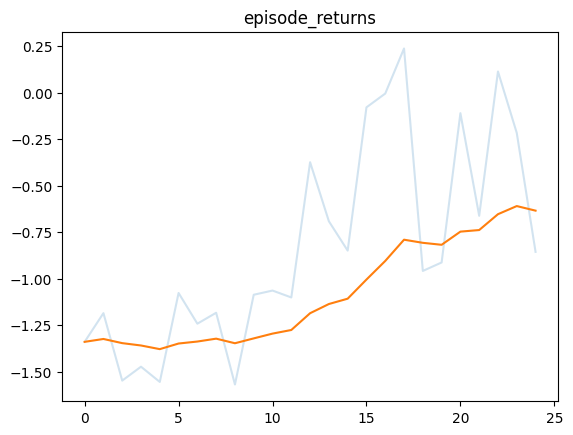

In [ ]:
def smooth(x, a=0.1):
  y = [x[0]]
  for xi in x[1:]:
    yi = a * xi + (1 - a) * y[-1]
    y.append(yi)
  return y


plt.plot(episode_returns, alpha=0.2)
plt.plot(smooth(episode_returns))
plt.title("episode_returns");
plt.show();

In [ ]:
# save models
model_path = "td3_actor.pth"
torch.save(actor.state_dict(), model_path)

In [ ]:
# load model for eval
envs_eval = gym.vector.SyncVectorEnv([lambda: make_env(prices_test)],
        autoreset_mode=gym.vector.AutoresetMode.SAME_STEP)
model = Actor(envs_eval).to(device)
model.load_state_dict(torch.load(model_path, map_location=device))
model.eval()

Actor(
  (fc1): Linear(in_features=8, out_features=32, bias=True)
  (fc2): Linear(in_features=32, out_features=32, bias=True)
  (fc_mu): Linear(in_features=32, out_features=1, bias=True)
)

In [ ]:
# evaluate the model
n_episodes_eval = 10
eval_returns = np.zeros(n_episodes_eval)
obs, _ = envs_eval.reset()
for i in range(n_episodes_eval):
  episode_done = False
  while not episode_done:
    with torch.no_grad():
      actions = model(torch.Tensor(obs).to(device))
      actions = actions.cpu().numpy()
    obs, rewards, terminateds, truncateds, infos = envs_eval.step(actions)

    if terminateds[0] or truncateds[0]:
      if 'final_info' in infos:
        print("buy_and_hold:", infos['final_info']['buy_and_hold'][0])
        if 'episode' in infos['final_info']:
          episode_done = True
          ret = infos['final_info']["episode"]["r"][0]
          print(f"episode={i}, return={ret}")
          eval_returns[i] = ret

envs_eval.close()

buy_and_hold: 1.2385153952326564
episode=0, return=0.8418916154219198
buy_and_hold: 0.9301787275425465
episode=1, return=0.34266182276304397
buy_and_hold: 1.134017502528427
episode=2, return=0.8405312961035271
buy_and_hold: 1.1567050583033625
episode=3, return=0.701814601012925
buy_and_hold: 1.1752928488148922
episode=4, return=0.8430297659422631
buy_and_hold: 1.010583760552163
episode=5, return=0.47939857903732164
buy_and_hold: 0.9938269799415244
episode=6, return=0.44822001240724785
buy_and_hold: 1.2178364010381577
episode=7, return=0.7737193808052911
buy_and_hold: 1.0230163723174486
episode=8, return=0.41745566568865455
buy_and_hold: 1.0061563214394182
episode=9, return=0.3311248953211564


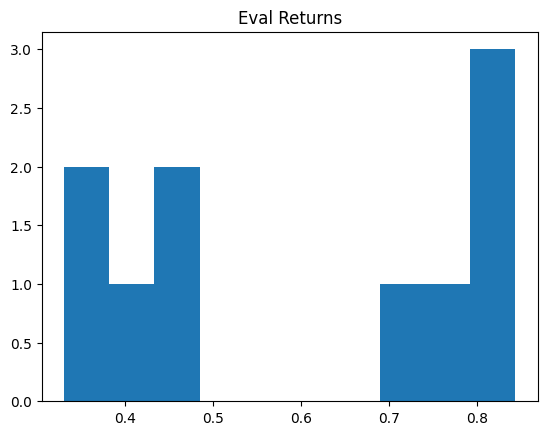

In [ ]:
# plot eval returns distribution
plt.hist(eval_returns)
plt.title("Eval Returns")
plt.show();

![](https://deeplearningcourses.com/notebooks_v3_pxl?sc=ajMgus4HVOdGR3CZkAAu7w&n=TD3+Trader)